# ex012_PHT3D_12

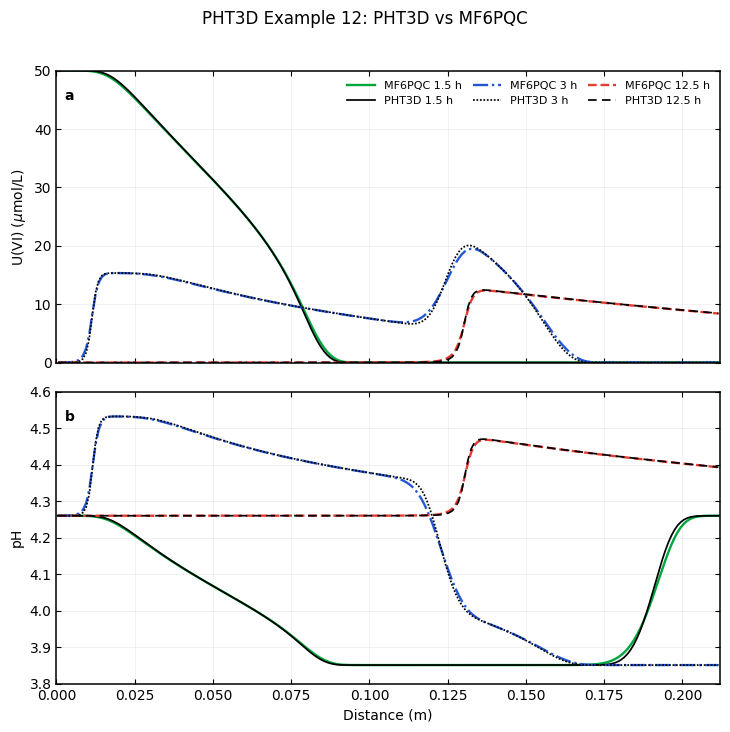

Time (h),1.50867,2.99039,12.5005
Variable,,,
U_6,1.55391e-07,2.83263e-07,9.20995e-08
pH,0.00564678,0.00524714,0.00155003
Tracer,1.24968e-08,1.19751e-08,5.46042e-10


In [1]:
import pandas as pd
from IPython.display import display

comparison_rows = []
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.dont_write_bytecode = True
CASE_DIR = next(
    p
    for root in (Path.cwd(), *Path.cwd().parents)
    for p in (root, root / "examples/ex012_PHT3D_12")
    if p.name == "ex012_PHT3D_12" and (p / "run.py").is_file()
)
sys.path.insert(0, str(CASE_DIR.parent))
from example_utils import runtime_path

CASE_FILE = CASE_DIR / "run.py"
INPUT_DIR = CASE_DIR / "input_data"
OUTPUT_DIR = runtime_path(CASE_FILE, "output")
SIMULATION_DIR = runtime_path(CASE_FILE, "simulation")
all_results = np.load(OUTPUT_DIR / "results.npy")
results = all_results[1:]
headings = np.atleast_1d(np.loadtxt(OUTPUT_DIR / "results_headings.txt", dtype=str))
result_times = np.load(OUTPUT_DIR / "results_times.npy")
source = np.load(INPUT_DIR / "PHT3D_12_results.npy")
official = {name: source[name].copy() for name in source.dtype.names}
expected_times = official["actual_hours"] / 24.0
np.testing.assert_allclose(result_times[1:], expected_times, rtol=0.0, atol=2e-10)
if results.shape != (3, len(headings), len(official["x"])):
    raise AssertionError(f"Unexpected result shape {results.shape}; rerun run.py")
row = {name: int(np.where(headings == name)[0][0]) for name in headings}
for name in ["U_6", "pH", "Tracer"]:
    for i, hour in enumerate(official["actual_hours"]):
        comparison_rows.append(
            {
                "Variable": name,
                "Time (h)": hour,
                "RMSE": np.sqrt(np.mean((results[i, row[name]] - official[name][i]) ** 2)),
            }
        )
x = official["x"]
nominal_hours = official["target_hours"]
colors = ("#00a63c", "#2457d6", "#e33d32")
model_styles = ("-", "-.", "--")
reference_styles = ("-", (0, (1, 1)), (0, (5, 3)))
fig, axes = plt.subplots(2, 1, figsize=(7.4, 7.2), sharex=True)
for index, (hour, color, model_style, reference_style) in enumerate(
    zip(nominal_hours, colors, model_styles, reference_styles, strict=False)
):
    axes[0].plot(
        x,
        results[index, row["U_6"]] * 1000000.0,
        color=color,
        linestyle=model_style,
        linewidth=1.7,
        label=f"MF6PQC {hour:g} h",
    )
    axes[0].plot(
        x,
        official["U_6"][index] * 1000000.0,
        color="black",
        linestyle=reference_style,
        linewidth=1.25,
        label=f"PHT3D {hour:g} h",
    )
    axes[1].plot(x, results[index, row["pH"]], color=color, linestyle=model_style, linewidth=1.7)
    axes[1].plot(x, official["pH"][index], color="black", linestyle=reference_style, linewidth=1.25)
axes[0].set_ylabel("U(VI) ($\\mu$mol/L)")
axes[1].set_ylabel("pH")
axes[1].set_xlabel("Distance (m)")
axes[0].set_ylim(0.0, 50.0)
axes[1].set_ylim(3.8, 4.6)
axes[1].set_xlim(0.0, 0.212)
axes[0].legend(
    ncol=3, fontsize=8, frameon=False, loc="upper right", columnspacing=1.0, handlelength=2.5
)
axes[0].text(0.012, 0.9, "a", transform=axes[0].transAxes, weight="bold")
axes[1].text(0.012, 0.9, "b", transform=axes[1].transAxes, weight="bold")
for axis in axes:
    axis.grid(alpha=0.18, linewidth=0.6)
    axis.tick_params(direction="in", top=True, right=True)
    for spine in axis.spines.values():
        spine.set_linewidth(1.1)
fig.suptitle("PHT3D Example 12: PHT3D vs MF6PQC", y=1.01)
fig.tight_layout()
plt.show()
comparison = pd.DataFrame(comparison_rows)
comparison = comparison.pivot(index="Variable", columns="Time (h)", values="RMSE").reindex(
    comparison["Variable"].drop_duplicates()
)
display(comparison.style.format("{:.6g}").format_index("{:.6g}", axis=1).set_uuid("ex012_1"))